### 4a. How would you design a signal that would detect similar informed actions in real-time?

This methodology has been implemented and run in q3 to identify the most informed trade already - see q3 for reference.

Effectively, we are looking for trades on the same side of the market (all of them are buy yes or all of them are sell yes), across multiple related markets, across multiple strikes, in the same short time span of time. The size of this cluster of trades (across family and strike) would be compared to historical sizes of clusters of trades, to decide if it is unusually large. 

We won't be able to know if the trade is very well-informed when it happens, though, because we don't know if it will make money in the future (in the next 10 or 30 min).  We can only establish that it is unusually large, a significant chunk of the trading volume in those family of contracts, so someone has strong conviction on a trade (informed with information that rest of the market doesn't see), or they just have a lot of capital to bet with (not informed) like a guy who is a billionaire and just wants to play around for fun. 

The assumption here is that we do have historical information on the distribution of sizes of clusters of trades in the same family.  And accordingly, in part 4B, it asks "What if you had no historical data...?", which we address below

### 4b. If you had no historical data, how would you roll out this signal to maximize your total expected profit in a three-month window, assuming you have a max loss tolerance of $1,000 and you estimate the signal has a 55% win probability on each trade (10% edge over a 50% breakeven) and there are 500 uncorrelated trades per day? Would you paper-trade or use your budget up?  

**Disclaimer: I'm carrying over some intuition from trading other assets such as stocks, bonds, commodities, which might not apply to prediction markets - let me know if that's the case. I also need to make some simplifying assumptions to carry out the Monte Carlo simulation in a reasonable way.**

**Assumption 1: For the purpose of this analysis, I am going to assume that capital consumption is symmetric at p = 0.1 vs. 0.9; otherwise, it makes the whole simulation much more complicated**

To simplify the Monte Carlo simulation here, this is what we'll go with: our ability to purchase "yes" at $0.1 vs. $0.9 is the same.

**Assumption 2: This is an aggressive assumption that sometimes does not play out in the real world: the delta threshold for stopping out of a trade is available to us, i.e. - if we set our stoploss at $0.2, it will be available to us, and the market won't move against us suddenly by $0.4 or $0.5.**

But that might not happen at all in real trading. Let's assume that you buy "yes" for a baseball team winning a game or that they can score k number of runs in an upcoming game, and then a news comes out that their star player got injured. The price of your contract might just crash from $0.7 to $0.3, with no intermediate prices in between. We've set up a stop loss of $0.2 perhaps, but we are already down $0.4 and there was no way to prevent this because the market gaps on sudden & material news releases

### The model: we are trading the move, not the settlement

**I am assuming that if I have a signal with 55% win rate, it predicts the direction of the next price move, not the final outcome.** We enter at price `p`, and exit as soon as the price has travelled `delta` in either direction. Right -> we make `delta`. Wrong -> we lose `delta`. We never hold to expiry.

The reason why I make this assumption is because the prompt says 500 uncorrelated trades per day.  If we hold a contract to maturity (such that it pays out $0 or $1), we would sit on positions for weeks or months.  The 500 trades per day assumes that we are trading these contracts intraday, before expiration, similar to how traders enter and exit call or put options before expiration.

### Why the calendar does not matter

500 trades/day for 64 days is 32,000 steps of a random walk. With a constant bet size
nothing in the walk depends on the date -- 250/day for 128 days would be the same
simulation. Ruin at trade 274 is ruin whether that is called Tuesday or not. So the
whole three-month window collapses to one number: **32,000 trades**.

In [1]:
import numpy as np
import pandas as pd

from utils import (simulate_naive_random_walk, ruin_probability_closed_form,
                   ruin_size_sweep, max_size_at_var)


### Test 1 -- does the simulation agree with the closed form?

Gambler's ruin gives the probability of ever touching a floor `k` bets away as
`((1-w)/w) ** k`. This is not the answer to anything -- it is a **unit test**. If the
Monte Carlo does not land near it, the Monte Carlo has a bug.

One caveat: the closed form assumes infinitely many trades, so it is a slight
over-estimate of a 32,000-trade simulation, which has only finitely many chances to
get there.

In [2]:
BET_SIZES = [10, 50, 100, 200]

rows = [simulate_naive_random_walk(x, n_paths = 5_000, seed = 1) for x in BET_SIZES]
sim  = pd.DataFrame(rows).set_index("bet_size")
sim["closed_form"] = [ruin_probability_closed_form(x) for x in BET_SIZES]

# Monte Carlo standard error on a proportion, so we can judge "close enough"
sim["mc_std_err"] = np.sqrt(sim["prob_ruin"] * (1 - sim["prob_ruin"]) / 5_000)
sim["diff_in_std_errs"] = ((sim["prob_ruin"] - sim["closed_form"]).abs()
                           / sim["mc_std_err"].replace(0, np.nan))

sim[["prob_ruin", "closed_form", "mc_std_err", "diff_in_std_errs"]].round(4)

,prob_ruin,closed_form,mc_std_err,diff_in_std_errs
bet_size,,,,
10,0.0000,0.0000,0.0000,NaN
50,0.0178,0.0181,0.0019,0.1452
100,0.1406,0.1344,0.0049,1.2550
200,0.3648,0.3666,0.0068,0.2714


In [3]:
# Assert it, so the notebook fails loudly rather than quietly drifting.
ok = (sim["diff_in_std_errs"].fillna(0) < 3).all()
assert ok, "simulation disagrees with the closed form by more than 3 standard errors"
print("PASS -- every bet size is within 3 standard errors of the closed form")

PASS -- every bet size is within 3 standard errors of the closed form


### Test 2 -- a case where the answer is known without any theory

Two sanity checks that do not depend on the gambler's-ruin formula at all:

- **A fair coin is ruined about 95% of the time.** At `win_prob = 0.50` the walk has zero
  drift, so it wanders until it hits the floor. Over a *finite* 32,000 trades it does not
  quite get there always: the reflection principle puts the chance of surviving a barrier
  `k` steps away at roughly `k * sqrt(2 / (pi * n))`, which for `k = 10` and `n = 32,000`
  is about 4.5%. So the expected ruin rate is near 95.5%, from a completely different
  argument than the one the model uses. Note this checks the *absorbing* barrier -- with
  ruined paths left running, the right expectation would be a final P&L near zero instead.
- **A big enough floor is unreachable.** With a $1 bet the floor is 1,000 losing bets
  away and a 55% win rate drifts upward the whole time, so ruin should never happen.


In [4]:
fair = simulate_naive_random_walk(100, win_prob = 0.50, n_paths = 2_000, seed = 7)
survive_est = 10 * np.sqrt(2 / (np.pi * 32_000))       # reflection principle, k = 1000/100
print(f"fair coin, $100 bet   -> prob of ruin     {fair['prob_ruin']:>10.4f}"
      f"   (expect ~{1 - survive_est:.3f})")

tiny = simulate_naive_random_walk(1, n_paths = 2_000, seed = 7)
print(f"$1 bet, 55% win rate  -> prob of ruin     {tiny['prob_ruin']:>10.4f}"
      f"   (expect 0)")

assert abs(fair["prob_ruin"] - (1 - survive_est)) < 0.02, "zero-edge ruin rate is off"
assert tiny["prob_ruin"] == 0.0, "a $1 bet should never reach -$1,000 here"
print("\nPASS -- both behave as expected")


fair coin, $100 bet   -> prob of ruin         0.9505   (expect ~0.955)
$1 bet, 55% win rate  -> prob of ruin         0.0000   (expect 0)

PASS -- both behave as expected


### The full result

In [5]:
sim[["prob_ruin", "closed_form", "median_ruin_trade",
     "mean_final_pnl", "median_final_pnl", "median_worst_pnl", "p05_worst_pnl"]].round(2)


,prob_ruin,closed_form,median_ruin_trade,mean_final_pnl,median_final_pnl,median_worst_pnl,p05_worst_pnl
bet_size,,,,,,,
10,0.00,0.00,NaN,32006.57,32040.0,-30.0,-150.0
50,0.02,0.02,191.0,157220.98,160000.0,-150.0,-750.0
100,0.14,0.13,71.0,275116.52,316800.0,-300.0,-1500.0
200,0.36,0.37,26.0,406704.88,612800.0,-600.0,-3000.0


### The P&L path -- watching the wiggle

Two panels, and both are needed. With a 10% edge over 32,000 trades the paths finish in
the hundreds of thousands, while the floor we care about is -$1,000. At full scale the
floor and $0 are the same line to the eye. The right panel rescales to the opening
stretch, which is where ruin actually happens.

Paths that hit the floor are drawn in red. They go flat there and stay flat: a trader
who breaches the loss limit is stopped out and books nothing afterwards.


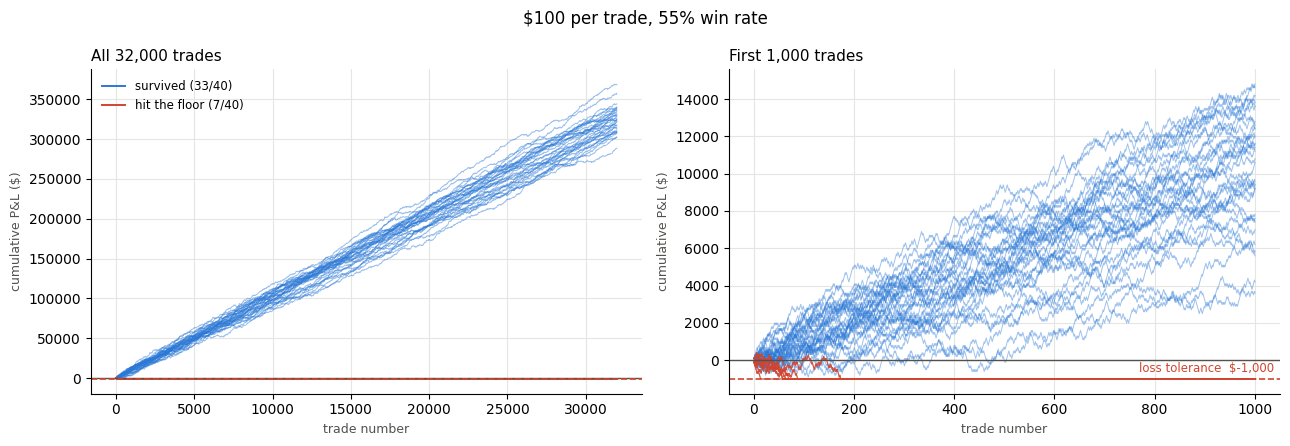

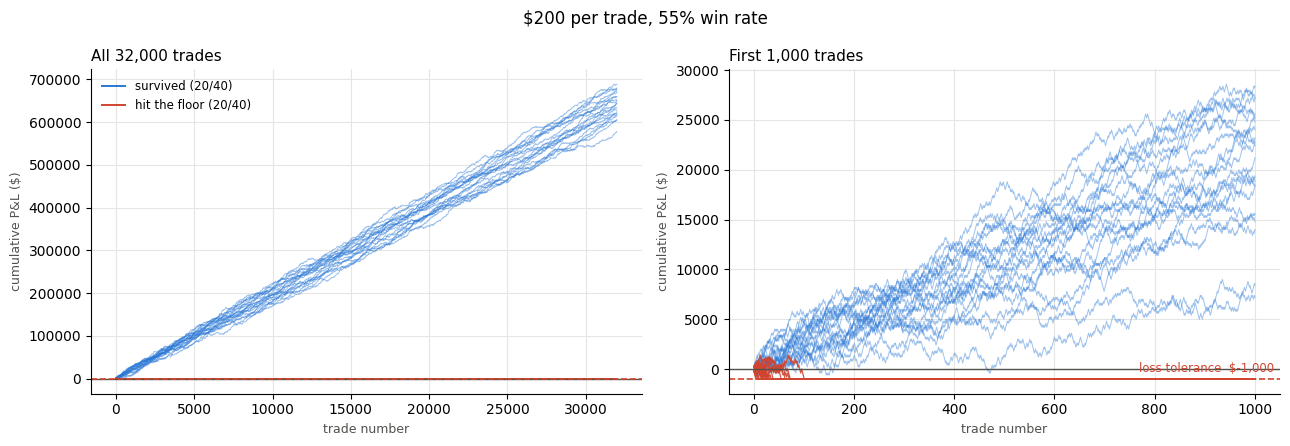

In [6]:
from utils import simulate_pnl_paths, plot_pnl_paths
import matplotlib.pyplot as plt

for bet in (100, 200):
    paths = simulate_pnl_paths(bet, n_paths = 40, seed = 3)
    plot_pnl_paths(paths, loss_limit = -1_000, zoom = 1_000)
    plt.suptitle(f"${bet} per trade, 55% win rate", fontsize = 12)
    plt.tight_layout()
    plt.show()

**What the picture shows that the table does not.**

Every red path breaks early. At $200 a trade the median failure happens on trade 25 and
the latest of them on trade 100 -- inside the first few minutes of the first day, before
any profit has built up to absorb a bad run. Survive the opening stretch and the edge
takes over and never really threatens you again. That is the whole question.

It also makes the sizing tension visible. At $200, 20 of the 40 paths never get past the
opening, and the 20 that do finish between $578k and $688k. Those survivors earn enough
that betting bigger still wins on average, which is why expected profit alone keeps
saying *bet more*. The VaR table is what settles it.


### How big can we trade? Ruin probability on a fine grid

The four-size grid above cannot locate the decision: between $100 (13% ruin) and $200
(37%) is exactly where it lives, and all three thresholds a risk manager would quote
fall in that gap. This sweeps $10 increments and reads off the sizes sitting at the
conventional VaR levels -- **1%, 5% and 10%**.

Two things to note about how this is measured. **Ruin is absorbing**: a path touching
-$1,000 books its loss at the trade that broke the limit and stops, rather than trading
on and recovering. And the reporting is on the **mean**, not the median, because the
question asks to maximise *total expected profit* -- and because while fewer than half
the paths blow up the median is still a survivor's number and barely moves.


In [7]:
# $10 increments, 10,000 independent three-month futures at each size
sweep = ruin_size_sweep()
sweep.round(4)


,prob_ruin,closed_form,mean_final_pnl,median_final_pnl
bet_size,,,,
10,0.0000,0.0000,31999.094,32000.0
20,0.0001,0.0000,63991.780,64000.0
30,0.0004,0.0011,95958.342,96000.0
40,0.0066,0.0066,127155.104,128000.0
50,0.0168,0.0181,157310.040,159900.0
60,0.0320,0.0330,185878.032,191760.0
70,0.0483,0.0493,213216.605,223440.0
80,0.0720,0.0736,237638.400,255040.0
90,0.0868,0.0900,263097.072,286560.0


Note the plateaus -- $100 and $110 carry the same ruin probability, as do $130/$140 and
$170/$180/$190. That is not noise. The walk only ever stands on multiples of the bet
size, so it cannot stop exactly on a floor that is not one: it crosses at the first
multiple at or beyond it. Both $100 and $110 need ten losing trades to get there, so
both face the same odds. The closed form uses `ceil` for the same reason and tracks the
simulation throughout.


In [8]:
# Largest size whose ruin probability stays inside each VaR threshold
max_size_at_var(sweep)


,max_bet_size,prob_ruin_there,mean_final_pnl
var_threshold,,,
0.01,40,0.0066,127155.104
0.05,70,0.0483,213216.605
0.10,90,0.0868,263097.072


## What step 1 shows

**1. When ruin happens, it happens almost immediately.** Median trade number at ruin is
**191** at a $50 bet, **71** at $100, **26** at $200. Not day 40 -- inside the first
hour of the first day. Over 32,000 trades the edge overwhelms the noise, so the only
real danger is the opening stretch, before any profit has accumulated to absorb a bad
run. That is the whole question.

**2. Expected profit alone says *bet more*, so the size has to come from the risk
limit.** Even with ruin absorbing, mean final P&L keeps climbing with bet size -- $127k
at $40, $263k at $90, $407k at $200 -- because the surviving paths earn enough to
outweigh the ones stopped at -$1,000. Maximising expected profit on its own would push
the size up until nearly every path blows up, so the binding constraint is the loss
tolerance, not the objective. Reading the size off the VaR table instead: **$40 to keep
ruin under 1%, $70 under 5%, $90 under 10%**. Kelly's formula says bet 10% of your money, which is $100 here. That is bigger than the
$90 our 10% risk line allows. Kelly assumes that when you lose you simply bet less next
time and never quite hit zero. Here you are stopped out at -$1,000, so Kelly's answer is
too big.

**3. The profit numbers are not credible, and that is a limitation of the setup, not a
finding.** Median final P&L is $32,040 at a $10 bet -- mechanically 32,000 trades x 10%
edge x $10. The simulation is claiming $1,000 becomes $32,000 in three months, and
$613,000 at a $200 bet. That assumes 32,000 genuinely independent 55% opportunities
with no market impact and no fees. Worth stating rather than letting the number stand.

### Still to do

- **Step 2 -- do the costs eat the edge?** Built below. The edge is `0.10 * delta`,
  which at a realistic `delta = 0.02` is **0.2c a contract**. Against that: a 1c spread
  and a `p(1-p)*0.07` fee on each leg crossed. Step 2 asks whether 0.2c can pay for
  that. Fees are folded in there rather than being a separate step.
- **Step 3 -- dynamic sizing**, resized every trade rather than daily. Wrinkle: purely
  proportional sizing can never reach zero, so `P(ruin)` becomes 0 by construction and
  a different failure definition is needed.
- **Answer the actual question asked:** paper-trade or use the budget? With 500 trades
  a day, the standard error on the win rate is `sqrt(0.55*0.45/500)` = 2.2%, so a
  single day of live trading at minimum size measures the edge nearly as precisely as
  paper trading would -- while earning rather than costing. That argues for trading
  small immediately and scaling with evidence, not for paper trading.

---

# Step 2 -- can the signal actually pay for its own costs?

Step 1 assumed trading was free. It is not.

#### First: how much is the signal actually worth?

Every trade is set up the same way. Enter, then exit once the price has moved **delta**
in either direction. Delta is both the profit target and the stop, the same distance
away, so every trade either wins delta or loses delta.

The signal is right 55% of the time. Out of 100 trades:

- 55 of them win delta
- 45 of them lose delta
- the average is `0.55*delta - 0.45*delta` = **0.10 x delta**

That is the same 10% edge as step 1, just measured per contract instead of per bet. And
it is smaller than it sounds: you predicted a 2 cent move and you keep 0.2 cents of it.
The 45% of trades where the signal is wrong cancel out most of the wins.

#### Second: what does a round trip cost?

**The spread.** With a 1c spread and `p` as the mid, the best bid is `p - 0.005` and the
best ask is `p + 0.005`. An **active** trader buys at the ask and sells at the bid, so a
round trip costs $0.01. A **passive** trader posts orders and waits: their bid gets hit
at `p - 0.005` and their offer gets lifted at `p + 0.005`, so they *collect* $0.01. The
gap between the two is $0.02 a round trip.

**The taker fee** is `p*(1-p)*0.07` on each leg you cross. At `p = 0.50` that is
`0.50 * 0.50 * 0.07` = **1.75 cents a contract**, each way. Making is free.

So the whole question is whether `0.10 * delta` can cover that.


In [9]:
from utils import simulate_signal_trades, signal_trade_ev

# How big is delta really? Checked against the book earlier:
#   largest full-session range of ANY of the 33 markets  0.035
#   median session range across the 33                   0.015
#   largest single 5-minute move seen anywhere           0.030
# So delta = 0.10 never happens in this dataset. 0.01-0.03 is realistic.

rows = []
for delta in (0.01, 0.02, 0.03, 0.10):
    rows.append({
        "delta": delta,
        "gross edge (0.10*delta)": 100 * 0.10 * delta,
        "ACTIVE  c/contract":  100 * signal_trade_ev(0.50, delta, 0.01),
        "PASSIVE c/contract":  100 * signal_trade_ev(0.50, delta, 0.01,
                                                     take_on_entry = False,
                                                     take_on_exit  = False),
    })
pd.DataFrame(rows).set_index("delta").round(3)

,gross edge (0.10*delta),ACTIVE c/contract,PASSIVE c/contract
delta,,,
0.01,0.1,-4.399,1.1
0.02,0.2,-4.297,1.2
0.03,0.3,-4.194,1.3
0.10,1.0,-3.430,2.0


#### Reading the table

Every number is **cents earned per contract**. Take the `delta = 0.02` row and add it up.

**Active** -- cross the spread to get in, and again to get out:

| | cents |
| --- | --- |
| gross edge, `0.10 x 2c` | +0.2 |
| pay the spread, in and out | -1.0 |
| taker fee, 1.75c on each of two legs | -3.5 |
| **total** | **-4.3** |

**Passive** -- post orders and wait, both times:

| | cents |
| --- | --- |
| gross edge | +0.2 |
| *collect* the spread instead of paying it | +1.0 |
| taker fee -- making is free | 0 |
| **total** | **+1.2** |

The costs do not depend on delta at all, which is why the active column hardly improves
as delta grows. It shifts a little only because a bigger move carries the exit price away
from 0.50, and `p*(1-p)` is largest at 0.50 -- so the fee on the exit leg falls slightly.
That is worth a few hundredths of a cent, against a 4.5 cent bill.


### Simulation A (active) vs Simulation B (passive)

Same signal, same 55% accuracy, same 32,000 trades, 100 contracts a trade. The only
difference is execution.

**A -- ACTIVE:** cross the spread both ways and pay the fee on both legs.
**B -- PASSIVE, best case:** every resting order fills, so no fees at all and we
collect the spread instead of paying it. This is an optimistic *bound*, not a plan --
in reality resting orders do not always fill, and they fill preferentially when we
are wrong.

In [10]:
DELTA, SPREAD, SIZE = 0.02, 0.01, 100

active  = simulate_signal_trades(p = 0.50, delta = DELTA, spread = SPREAD,
                                 n_contracts = SIZE, seed = 5)
passive = simulate_signal_trades(p = 0.50, delta = DELTA, spread = SPREAD,
                                 n_contracts = SIZE, seed = 5,
                                 take_on_entry = False, take_on_exit = False)

for name, r in (("ACTIVE ", active), ("PASSIVE", passive)):
    print(f"{name}  {100*r['ev_per_contract']:+7.3f} c/contract   "
          f"${r['ev_per_trade']:+8.2f} per trade   "
          f"${r['total_pnl']:+12,.0f} after 32,000 trades")

ACTIVE    -4.303 c/contract   $   -4.30 per trade   $    -137,688 after 32,000 trades
PASSIVE   +1.194 c/contract   $   +1.19 per trade   $     +38,216 after 32,000 trades


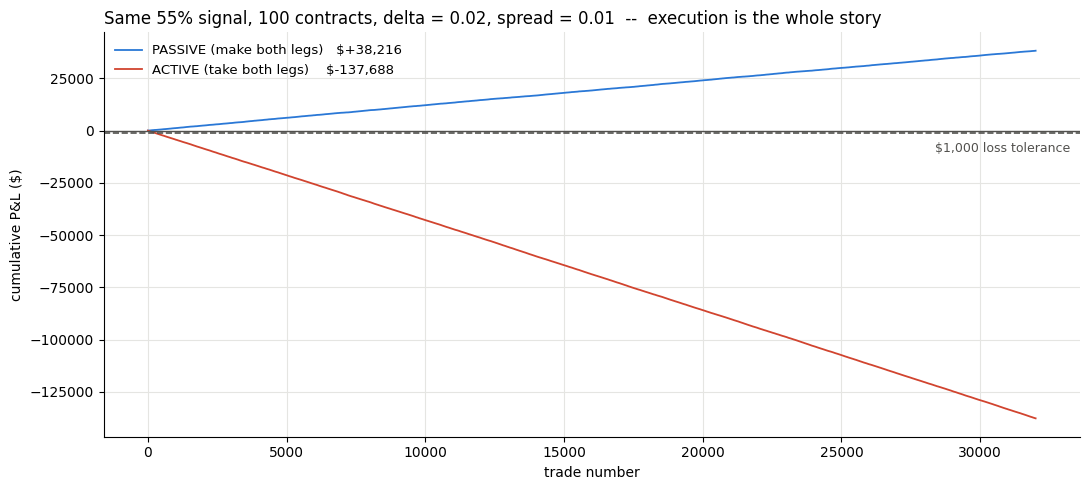

In [11]:
fig, ax = plt.subplots(figsize = (11, 5))

ax.plot(passive["pnl_path"], color = "#2a78d6", lw = 1.3,
        label = f"PASSIVE (make both legs)   ${passive['total_pnl']:+,.0f}")
ax.plot(active["pnl_path"],  color = "#d1442f", lw = 1.3,
        label = f"ACTIVE (take both legs)    ${active['total_pnl']:+,.0f}")

ax.axhline(0, color = "#52514e", lw = 1)
ax.axhline(-1_000, color = "#52514e", lw = 1.2, ls = "--")
ax.annotate("$1,000 loss tolerance", xy = (0.99, -1_000),
            xycoords = ("axes fraction", "data"), xytext = (0, -14),
            textcoords = "offset points", ha = "right", fontsize = 9, color = "#52514e")

ax.set_title(f"Same 55% signal, {SIZE} contracts, delta = {DELTA}, spread = {SPREAD}"
             "  --  execution is the whole story", fontsize = 12, loc = "left")
ax.set_xlabel("trade number"); ax.set_ylabel("cumulative P&L ($)")
ax.legend(fontsize = 9.5, frameon = False)
ax.grid(color = "#e5e5e2", lw = 0.8); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

In [12]:
# How much of the passive profit is the SIGNAL, and how much is just the spread?
with_signal = signal_trade_ev(0.50, DELTA, SPREAD, signal_accuracy = 0.55,
                              take_on_entry = False, take_on_exit = False)
no_signal   = signal_trade_ev(0.50, DELTA, SPREAD, signal_accuracy = 0.50,
                              take_on_entry = False, take_on_exit = False)

print(f"passive with a 55% signal : {100*with_signal:+.3f} c/contract")
print(f"passive with NO signal    : {100*no_signal:+.3f} c/contract")
print(f"the signal is worth       : {100*(with_signal-no_signal):+.3f} c/contract"
      f"  ({100*(with_signal-no_signal)/(100*with_signal):.0%} of the total)")

passive with a 55% signal : +1.200 c/contract
passive with NO signal    : +1.000 c/contract
the signal is worth       : +0.200 c/contract  (17% of the total)


## What step 2 shows

**1. Active trading loses money, and not narrowly.** At a realistic 2c move the
active strategy loses about 4.3c per contract while the signal's gross edge is only
0.2c. Costs are twenty times the edge. The active line falls through the $1,000 loss
tolerance almost immediately and never comes back.

**2. It is not a question of finding a bigger delta.** Break-even for the active
strategy needs delta near 0.29. The largest move any of these 33 markets made in the
entire session was 0.035. The gap is an order of magnitude, so no plausible holding
period rescues taking.

**3. Passive execution flips the sign** -- from -4.3c to +1.2c a contract. Making is
free, and instead of paying the spread you collect it.

**4. But most of that profit is not the signal.** Running the passive case with the
signal turned off (50% accuracy, pure coin flip) still earns 1.0c a contract. The
signal adds 0.2c. **Five sixths of the money is spread capture, not prediction.**

So the honest answer to "how would you roll out this signal" is that at 55% accuracy
it is not a standalone strategy. It is a tilt on a market-making business. The real
questions become how much size to quote, and how badly the quotes get adversely
selected -- because a resting order fills exactly when someone better informed wants
the other side. That is the same risk Q3 asks about, and it is what would eat the
1.0c.

**Assumption to flag:** Simulation B assumes every resting order fills. That is the
optimistic bound. A real maker only gets filled on some quotes, and disproportionately
the wrong ones.

### TO DO: STILL NEED TO ANSWER QUESTION ABOUT SCALING UP OR DOWN ACCORDING TO P&L. AND ALSO NEED TO ANSWER QUESTION ABOUT SHOULD WE PAPER TRADE VS. JUST TRADE WITH REAL MONEY IMMEDIATELY?

imo - If we are sure that the signal has a consistent 55% win rate, we can just trade.  

if we need some data, then we should paper trade to get some data (to build a confidence interval around if its win rate is truly 55%, statistically above the baseline of 50%).  

And if we believe there is alpha decay (the signal gets worse / less profitable over time), then we should track the rolling / trailing average of our win rate in the past 100-200 trades, to see if it is drifting from 55% towards 50%, imo